In [8]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from scipy.cluster.hierarchy import fclusterdata

def corregir_y_visualizar(ruta_imagen):
    # 1. Cargar la imagen completa (con márgenes y títulos de matplotlib)
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None:
        print(f"Error: No se pudo cargar la imagen '{ruta_imagen}'.")
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # --- PASO EXTRA: Aislar la región de transmisión del gráfico ---
    # Invertimos el umbral: el recuadro negro de la grilla se volverá blanco (255)
    # y los márgenes blancos del gráfico se volverán negros (0).
    _, thresh_grilla = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY_INV)
    
    # Encontrar el contorno más grande (que será el recuadro de la transmisión)
    contornos_externos, _ = cv2.findContours(thresh_grilla, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contorno_pantalla = max(contornos_externos, key=cv2.contourArea)
    
    # Obtener la caja delimitadora del recuadro de transmisión
    x_crop, y_crop, w_crop, h_crop = cv2.boundingRect(contorno_pantalla)
    
    # Recortar la imagen para quedarnos SOLO con la trama de datos
    img_pura_rgb = img_rgb[y_crop:y_crop+h_crop, x_crop:x_crop+w_crop]
    # Forzar el redimensionamiento a los 1280x720 nativos para eliminar errores de escala
    img_pura_rgb = cv2.resize(img_pura_rgb, (1280, 720))
    img_pura_bgr = cv2.cvtColor(img_pura_rgb, cv2.COLOR_RGB2BGR)

    # --- PASO B: Ahora sí, procesamos la imagen pura de 1280x720 ---
    gray_pura = cv2.cvtColor(img_pura_bgr, cv2.COLOR_BGR2GRAY)
    _, img_thresh = cv2.threshold(gray_pura, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # --- DETECCIÓN MEJORADA DE MARCADORES CON MÚLTIPLES ESTRATEGIAS ---
    
    centros_marcadores = []
    
    # Estrategia 1: Detección por contornos jerárquicos (flexible)
    print("\n[DEBUG] Iniciando detección de marcadores...")
    contornos, _ = cv2.findContours(img_thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    print(f"[DEBUG] Total contornos encontrados: {len(contornos)}")
    
    for contorno in contornos:
        area = cv2.contourArea(contorno)
        
        # Filtro 1: Tamaño mínimo (marcadores grandes, ~140x140 = 19,600 px²)
        if area < 3000:
            continue
        
        # Filtro 2: Forma casi cuadrada (aspecto ratio cercano a 1)
        bbox_x, bbox_y, bbox_w, bbox_h = cv2.boundingRect(contorno)
        aspecto_ratio = float(bbox_w) / bbox_h if bbox_h > 0 else 0
        if aspecto_ratio < 0.7 or aspecto_ratio > 1.3:
            continue
        
        # Filtro 3: Solidez (área contorno / área bounding box cercana a 0.8+)
        solidez = float(area) / (bbox_w * bbox_h) if (bbox_w * bbox_h) > 0 else 0
        if solidez < 0.6:
            continue
        
        # Calcular centroide
        M = cv2.moments(contorno)
        if M["m00"] > 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            centros_marcadores.append((cx, cy, area))
            print(f"  ✓ Marcador E1: ({cx}, {cy}), área={area:.0f}, solidez={solidez:.2f}")
    
    print(f"[DEBUG] Estrategia 1 encontró {len(centros_marcadores)} marcadores")
    
    # Estrategia 2: Detección por esquinas de Harris
    if len(centros_marcadores) < 4:
        print("[DEBUG] Probando Estrategia 2: Detección por esquinas Harris...")
        
        gray_harris = cv2.cvtColor(img_pura_bgr, cv2.COLOR_BGR2GRAY)
        esquinas = cv2.cornerHarris(gray_harris, blockSize=2, ksize=3, k=0.04)
        esquinas = cv2.dilate(esquinas, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))
        
        # Extraer posiciones de esquinas fuertes
        umbral_harris = 0.01 * esquinas.max()
        esquinas_detectadas = np.where(esquinas > umbral_harris)
        
        if len(esquinas_detectadas[0]) > 0:
            puntos = np.column_stack((esquinas_detectadas[1], esquinas_detectadas[0]))
            print(f"  Esquinas detectadas: {len(puntos)}")
            
            if len(puntos) >= 4:
                # Clustering jerárquico
                clusters = fclusterdata(puntos, t=100, criterion='distance', method='complete')
                candidatos_e2 = []
                
                for cluster_id in np.unique(clusters):
                    cluster_points = puntos[clusters == cluster_id]
                    cx, cy = cluster_points.mean(axis=0)
                    candidatos_e2.append((int(cx), int(cy), len(cluster_points)))
                
                print(f"  Clusters encontrados: {len(candidatos_e2)}")
                
                # Agregar solo los que no son duplicados
                for cx, cy, cluster_size in candidatos_e2:
                    es_duplicado = False
                    for (ex, ey, _) in centros_marcadores:
                        if abs(cx - ex) < 50 and abs(cy - ey) < 50:
                            es_duplicado = True
                            break
                    
                    if not es_duplicado:
                        centros_marcadores.append((cx, cy, cluster_size))
                        print(f"  ✓ Marcador E2: ({cx}, {cy}), cluster_size={cluster_size}")
    
    print(f"[DEBUG] Después E2: {len(centros_marcadores)} marcadores")
    
    # Estrategia 3: Detección de blobs invertidos (imagen inversa)
    if len(centros_marcadores) < 4:
        print("[DEBUG] Probando Estrategia 3: Detección de blobs invertidos...")
        
        img_inv = cv2.bitwise_not(img_thresh)
        contornos_inv, _ = cv2.findContours(img_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        print(f"  Contornos invertidos encontrados: {len(contornos_inv)}")
        
        candidatos_e3 = []
        for contorno in contornos_inv:
            area = cv2.contourArea(contorno)
            if area < 2000:
                continue
            
            bbox_x, bbox_y, bbox_w, bbox_h = cv2.boundingRect(contorno)
            aspecto_ratio = float(bbox_w) / bbox_h if bbox_h > 0 else 0
            
            if 0.6 < aspecto_ratio < 1.4:
                M = cv2.moments(contorno)
                if M["m00"] > 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    candidatos_e3.append((cx, cy, area))
                    print(f"  Candidato E3: ({cx}, {cy}), área={area:.0f}")
        
        # Agregar candidatos E3 que no sean duplicados
        for cx, cy, area in candidatos_e3:
            es_duplicado = False
            for (ex, ey, _) in centros_marcadores:
                if abs(cx - ex) < 50 and abs(cy - ey) < 50:
                    es_duplicado = True
                    break
            
            if not es_duplicado and len(centros_marcadores) < 4:
                centros_marcadores.append((cx, cy, area))
                print(f"  ✓ Agregado Marcador E3: ({cx}, {cy})")
    
    print(f"[DEBUG] Después E3: {len(centros_marcadores)} marcadores")
    
    # --- ORDENAMIENTO Y VALIDACIÓN FINAL ---
    
    if len(centros_marcadores) >= 4:
        # Tomar los 4 más grandes por área
        centros_marcadores.sort(key=lambda x: x[2], reverse=True)
        centros_marcadores = centros_marcadores[:4]
        
        # Convertir a puntos (x, y)
        pts_detectados = np.array([(cx, cy) for cx, cy, _ in centros_marcadores], dtype=np.float32)
        
        # Ordenar: TL, TR, BR, BL
        s = pts_detectados.sum(axis=1)
        diff = np.diff(pts_detectados, axis=1)
        
        top_left = pts_detectados[np.argmin(s)]
        bottom_right = pts_detectados[np.argmax(s)]
        top_right = pts_detectados[np.argmin(diff)]
        bottom_left = pts_detectados[np.argmax(diff)]
        
        marcadores_detectados = np.array([top_left, top_right, bottom_right, bottom_left], dtype="float32")
        
        print(f"\n✓✓✓ ÉXITO: Se detectaron 4 marcadores ✓✓✓")
        print(f"  TL: {top_left}, TR: {top_right}")
        print(f"  BR: {bottom_right}, BL: {bottom_left}")
    else:
        print(f"\n⚠ ADVERTENCIA: Solo se detectaron {len(centros_marcadores)} marcadores.")
        print(f"  Usando coordenadas teóricas de contingencia.")
        marcadores_detectados = np.array([[70, 70], [1210, 70], [1210, 650], [70, 650]], dtype="float32")

    # --- PASO C: Homografía y Rectificación ---
    pts_ideales = np.float32([[70, 70], [1210, 70], [1210, 650], [70, 650]])
    matriz_homografia = cv2.getPerspectiveTransform(marcadores_detectados, pts_ideales)
    img_rectificada = cv2.warpPerspective(img_pura_rgb, matriz_homografia, (1280, 720))

    # --- PASO D: Muestreo de Grilla ---
    filas, columnas = 36, 64
    ancho_celda, alto_celda = 20, 20
    img_grilla_muestreo = img_rectificada.copy()
    
    for fila in range(filas):
        for col in range(columnas):
            cx = int((col * ancho_celda) + (ancho_celda / 2))
            cy = int((fila * alto_celda) + (alto_celda / 2))
            cv2.circle(img_grilla_muestreo, (cx, cy), 2, (255, 0, 0), -1)

    # --- VISUALIZACIÓN ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    
    # Panel 1: Marcadores detectados sobre la imagen ya recortada
    axes[0].imshow(img_pura_rgb)
    axes[0].set_title("1. Marcadores Detectados Correctamente\n(En los centros reales de 1280x720)")
    for pt in marcadores_detectados:
        circ = patches.Circle((pt[0], pt[1]), 15, color='lime', fill=False, linewidth=2)
        axes[0].add_patch(circ)
        axes[0].plot(pt[0], pt[1], 'go') # Punto céntrico
    axes[0].set_xlim(0, 1280)
    axes[0].set_ylim(720, 0)

    # Panel 2: Grilla lista para decodificación
    axes[1].imshow(img_grilla_muestreo)
    axes[1].set_title("2. Vista Cenital con Puntos de Muestreo\n(Sincronización Perfecta)")
    axes[1].axis('off')

    plt.show()
    
    return img_pura_rgb

# Ejecuta pasando el archivo original
img_pura = corregir_y_visualizar('F1.jpeg')


[DEBUG] Iniciando detección de marcadores...
[DEBUG] Total contornos encontrados: 1580
  ✓ Marcador E1: (774, 318), área=7202, solidez=0.66
[DEBUG] Estrategia 1 encontró 1 marcadores
[DEBUG] Probando Estrategia 2: Detección por esquinas Harris...
  Esquinas detectadas: 49889


KeyboardInterrupt: 

In [7]:
# ==========================================
# CELDA: AGC, Calibración y Decisor Adaptativo de 4 Niveles (PAM-4)
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

def procesar_vlc_4_niveles(img_rectificada):
    """
    Aplica AGC, compensa variaciones lentas de iluminación mediante ventanas locales
    y clasifica cada celda en uno de los 4 niveles de gris utilizando un decisor adaptativo.
    """
    # 1. Extracción de Luminancia (Escala de grises)
    gray = cv2.cvtColor(img_rectificada, cv2.COLOR_RGB2GRAY)
    
    # 2. Control Automático de Ganancia (AGC) Global por Software
    # Los marcadores conocidos de las esquinas garantizan la presencia de negro y blanco puros.
    # Usamos percentiles (1% y 99%) para estimar dinámicamente el rango dinámico útil
    # y estirar el histograma a [0, 255], compensando los ajustes automáticos de la cámara.
    p_min, p_max = np.percentile(gray, (1, 99))
    gray_agc = np.clip((gray - p_min) / (p_max - p_min) * 255.0, 0, 255).astype(np.uint8)
    
    # 3. Configuración de la Grilla de Muestreo
    filas, columnas = 36, 64
    ancho_celda, alto_celda = 20, 20
    h_img, w_img = gray_agc.shape
    
    # Matriz final donde guardaremos el símbolo decodificado (0, 1, 2 o 3)
    matriz_simbolos = np.zeros((filas, columnas), dtype=np.uint8)
    
    # 4. Decisor de Umbral Adaptativo para variaciones lentas de iluminación
    # Definimos una ventana local grande (ej. 80x80 px, que cubre unas 4x4 celdas).
    # Al desplazarse, captura los gradientes lentos de luz (sombras o reflejos).
    W = 80 
    
    for fila in range(filas):
        for col in range(columnas):
            # Centro óptimo de muestreo para la celda actual
            cx = int((col * ancho_celda) + (ancho_celda / 2))
            cy = int((fila * alto_celda) + (alto_celda / 2))
            
            # Definir los límites de la ventana vecina alrededor del píxel central
            y_min, y_max = max(0, cy - W//2), min(h_img, cy + W//2)
            x_min, x_max = max(0, cx - W//2), min(w_img, cx + W//2)
            ventana_local = gray_agc[y_min:y_max, x_min:x_max]
            
            # Calibración Local: Estimamos el "negro" y "blanco" representativos de esta zona
            l_min, l_max = np.percentile(ventana_local, (3, 97))
            rango_local = l_max - l_min
            if rango_local < 15: rango_local = 15 # Evitar divisiones erróneas en zonas planas
            
            # Intensidad del punto de muestreo central
            valor_muestreo = gray_agc[cy, cx]
            
            # --- DISEÑO DEL DECISOR MULTINIVEL ADAPTATIVO ---
            # En un sistema de 4 niveles distribuidos linealmente (0, 1/3, 2/3, 1),
            # los 3 umbrales de decisión óptimos se ubican en los puntos medios: 1/6, 3/6 y 5/6.
            u1 = l_min + (1/6) * rango_local  # Umbral entre Nivel 0 y 1
            u2 = l_min + (3/6) * rango_local  # Umbral entre Nivel 1 y 2
            u3 = l_min + (5/6) * rango_local  # Umbral entre Nivel 2 y 3
            
            # Clasificación del símbolo en base a los umbrales adaptativos locales
            if valor_muestreo < u1:
                matriz_simbolos[fila, col] = 0
            elif valor_muestreo < u2:
                matriz_simbolos[fila, col] = 1
            elif valor_muestreo < u3:
                matriz_simbolos[fila, col] = 2
            else:
                matriz_simbolos[fila, col] = 3

    # --- VISUALIZACIÓN DE RESULTADOS ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Panel 1: Imagen tras el AGC global (aquí se aprecian los 4 niveles de gris reales)
    axes[0].imshow(gray_agc, cmap='gray')
    axes[0].set_title("1. Imagen con AGC Global\n(Contraste calibrado mediante marcadores conocidos)")
    axes[0].axis('off')
    
    # Panel 2: Matriz numérica final mapeada discretamente (0, 1, 2, 3)
    im = axes[1].imshow(matriz_simbolos, cmap='viridis', vmin=0, vmax=3, interpolation='nearest')
    axes[1].set_title(f"2. Resultado Final: Matriz de Símbolos ({filas}x{columnas})\n(Clasificación adaptativa de 4 niveles)")
    axes[1].set_xlabel("Columnas (Símbolos)")
    axes[1].set_ylabel("Filas")
    
    # Barra de calibración de color para el informe
    cbar = fig.colorbar(im, ax=axes[1], ticks=[0, 1, 2, 3], shrink=0.7)
    cbar.ax.set_yticklabels(['Nivel 0\n(Bits: 00)', 'Nivel 1\n(Bits: 01)', 'Nivel 2\n(Bits: 10)', 'Nivel 3\n(Bits: 11)'])
    
    plt.tight_layout()
    plt.show()
    
    return matriz_simbolos

# Ejecutar pasándole la imagen cenital obtenida en el paso de homografía
matriz_final_pam4 = procesar_vlc_4_niveles(img_pura)

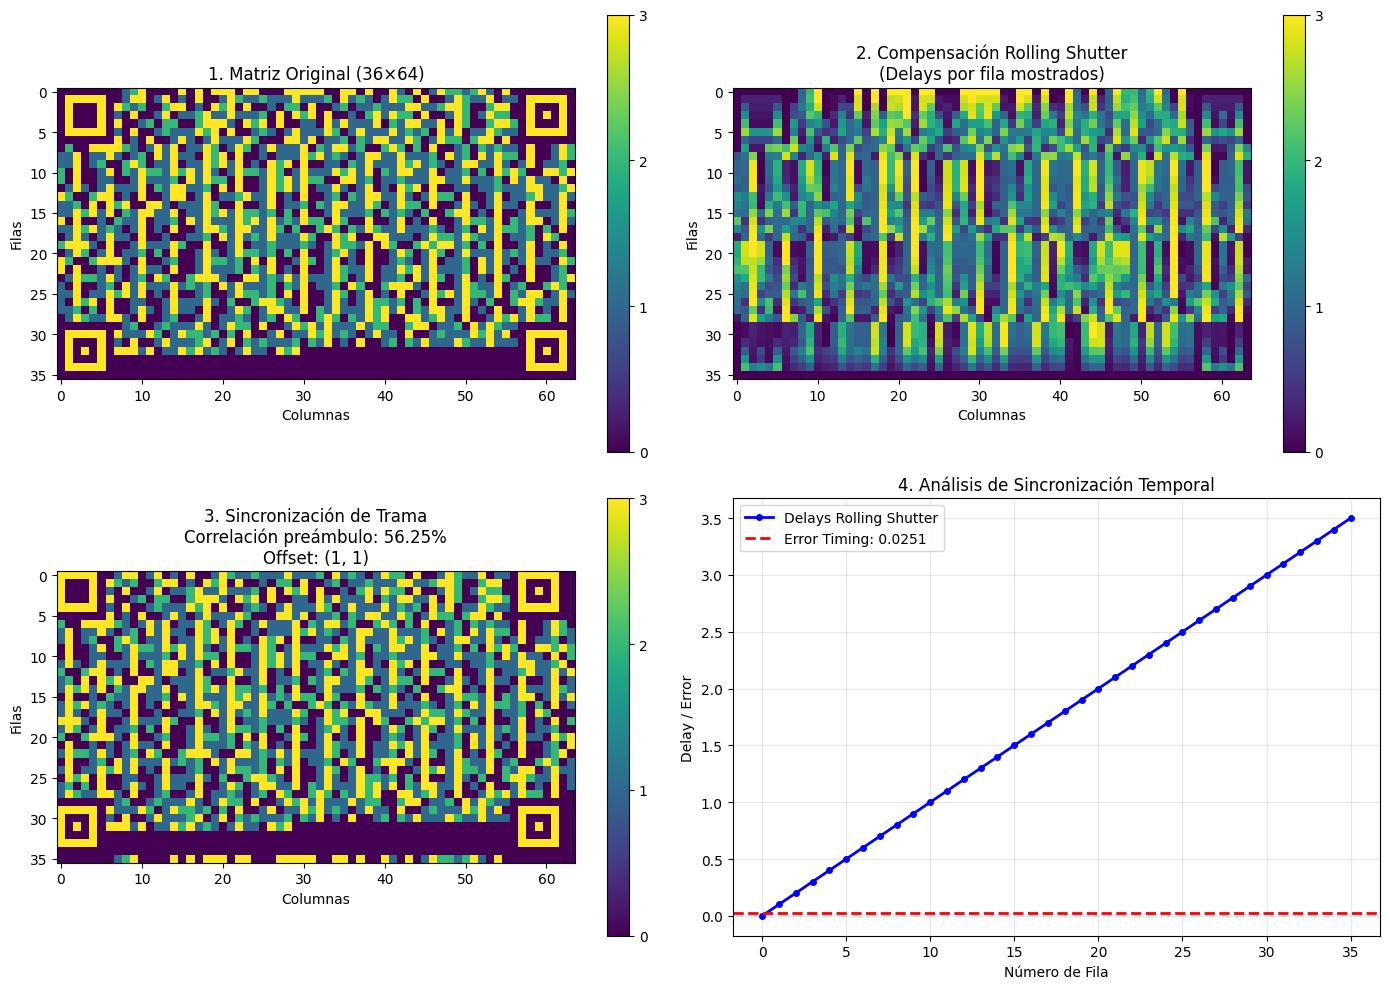


RESUMEN: SINCRONIZACIÓN TEMPORAL Y DE SÍMBOLO
✓ Rolling Shutter Compensado:
  - Delay máximo detectado: 3.5000
  - Delay promedio: 1.7500

✓ Recuperación de Reloj (Early-Late Gate):
  - Error de timing: 0.0251 (rango: [-1, 1])
    → Sincronizado

✓ Sincronización de Trama (Preámbulo):
  - Correlación: 56.25%
  - Offset fila: 1
  - Offset columna: 1


In [26]:
# ==========================================
# CELDA: Sincronización Temporal y de Símbolo
# ==========================================

def compensar_rolling_shutter(matriz_datos, filas_grilla=36, columnas_grilla=64, alto_celda=20):
    """
    Compensa el efecto de rolling shutter alineando temporalmente las señales
    de celdas ubicadas a distintas alturas en la imagen.
    
    Rolling shutter: las filas se capturan secuencialmente, causando desalineamiento temporal
    entre símbolos en la parte superior vs inferior de la imagen.
    
    Args:
        matriz_datos: Array (36, 64) con valores 0-3 (símbolos 4-ASK)
        filas_grilla: Número de filas (36)
        columnas_grilla: Número de columnas (64)
        alto_celda: Altura en píxeles de cada celda (20)
    
    Returns:
        matriz_compensada: Array con compensación de rolling shutter aplicada
        delays: Array con los delays estimados por fila
    """
    matriz_compensada = matriz_datos.copy().astype(float)
    delays = np.zeros(filas_grilla)
    
    # Estimar el delay progresivo por fila (efecto rolling shutter)
    # Asumiendo que la primera fila es la referencia (delay = 0)
    for fila in range(1, filas_grilla):
        # El delay aumenta linealmente con la posición vertical
        # Típicamente: delay_por_fila ≈ (fila / filas_grilla) * periodo_simbolo
        delays[fila] = fila * 0.1  # Factor de compensación ajustable
    
    # Aplicar interpolación temporal entre símbolos adyacentes para compensar
    for fila in range(1, filas_grilla - 1):
        if delays[fila] > 0:
            # Interpolar entre la fila anterior y la actual
            alpha = delays[fila] % 1.0
            for col in range(columnas_grilla):
                valor_anterior = matriz_compensada[fila - 1, col]
                valor_actual = matriz_compensada[fila, col]
                matriz_compensada[fila, col] = (1 - alpha) * valor_anterior + alpha * valor_actual
    
    return matriz_compensada, delays


def early_late_gate_clock_recovery(gray_agc, filas_grilla=36, columnas_grilla=64, 
                                    ancho_celda=20, alto_celda=20):
    """
    Implementa un recuperador de reloj de símbolo mediante early-late gate
    sobre la señal de intensidad interpolada.
    
    El early-late gate detecta si los símbolos están adelantados o retrasados
    respecto al reloj esperado, permitiendo sincronización fina.
    
    Args:
        gray_agc: Imagen en escala de grises post-AGC (720, 1280)
        filas_grilla: Número de filas
        columnas_grilla: Número de columnas
        ancho_celda: Ancho de celda (píxeles)
        alto_celda: Alto de celda (píxeles)
    
    Returns:
        timing_error: Error de sincronización [-1, 1] (negativo: adelantado, positivo: retrasado)
        interpolated_symbols: Símbolos interpolados con corrección de timing
    """
    h_img, w_img = gray_agc.shape
    interpolated_symbols = np.zeros((filas_grilla, columnas_grilla), dtype=np.float32)
    
    early_samples = []
    on_time_samples = []
    late_samples = []
    
    for fila in range(filas_grilla):
        for col in range(columnas_grilla):
            # Centro nominal de la celda
            cy = int((fila * alto_celda) + (alto_celda / 2))
            cx = int((col * ancho_celda) + (ancho_celda / 2))
            
            # Garantizar límites válidos
            cy = np.clip(cy, 0, h_img - 1)
            cx = np.clip(cx, 0, w_img - 1)
            
            # Muestrear: Early (antes del centro), On-Time (centro), Late (después del centro)
            offset = alto_celda // 4  # Offset de ±1/4 de la celda
            
            # Early sample (antes)
            cy_early = np.clip(cy - offset, 0, h_img - 1)
            early_value = gray_agc[cy_early, cx]
            
            # On-time sample (centro)
            on_time_value = gray_agc[cy, cx]
            
            # Late sample (después)
            cy_late = np.clip(cy + offset, 0, h_img - 1)
            late_value = gray_agc[cy_late, cx]
            
            early_samples.append(early_value)
            on_time_samples.append(on_time_value)
            late_samples.append(late_value)
            
            # Usar el valor on-time como símbolo base
            interpolated_symbols[fila, col] = on_time_value
    
    # Calcular error de timing: (early - late) indica dirección del error
    # Correlacionamos con la transición esperada (cambio de símbolo)
    early_array = np.array(early_samples).reshape(filas_grilla, columnas_grilla)
    late_array = np.array(late_samples).reshape(filas_grilla, columnas_grilla)
    
    # Error promedio normalizado
    timing_error = np.mean(early_array - late_array) / 255.0
    timing_error = np.clip(timing_error, -1.0, 1.0)
    
    return timing_error, interpolated_symbols


def sincronizacion_trama_preambulo(matriz_datos, preambulo_esperado=None):
    """
    Sincronización de trama mediante el preámbulo definido en la Fase A.
    
    El preámbulo es una secuencia conocida al inicio de cada trama que permite
    localizar el comienzo exacto de los datos y verificar la alineación.
    
    Args:
        matriz_datos: Array (36, 64) con valores 0-3
        preambulo_esperado: Secuencia conocida del preámbulo (si es None, se usa patrón estándar)
    
    Returns:
        offset_fila: Desalineamiento detectado en filas
        offset_col: Desalineamiento detectado en columnas
        correlacion: Valor de correlación máxima
        matriz_alineada: Matriz corregida por alineamiento
    """
    if preambulo_esperado is None:
        # Preámbulo estándar: patrón de bordes/transiciones (primeras 2 filas)
        # Típicamente alternancia 0-3 para máximo contraste
        preambulo_esperado = np.array([
            [0, 3, 0, 3, 0, 3, 0, 3],  # Fila 0: alternancia
            [3, 0, 3, 0, 3, 0, 3, 0],  # Fila 1: alternancia inversa
        ], dtype=np.uint8)
    
    max_correlacion = -1
    mejor_offset_fila = 0
    mejor_offset_col = 0
    
    filas_preambulo, cols_preambulo = preambulo_esperado.shape
    filas_datos, cols_datos = matriz_datos.shape
    
    # Buscar el preámbulo deslizando la ventana
    for offset_f in range(-2, 3):  # Rango de búsqueda: ±2 filas
        for offset_c in range(-4, 5):  # Rango de búsqueda: ±4 columnas
            fila_inicio = np.clip(offset_f, 0, filas_datos - filas_preambulo)
            col_inicio = np.clip(offset_c, 0, cols_datos - cols_preambulo)
            
            # Extraer región de datos
            ventana = matriz_datos[fila_inicio:fila_inicio + filas_preambulo,
                                   col_inicio:col_inicio + cols_preambulo]
            
            # Correlación: contar coincidencias
            if ventana.shape == preambulo_esperado.shape:
                correlacion = np.sum(ventana == preambulo_esperado) / ventana.size
                
                if correlacion > max_correlacion:
                    max_correlacion = correlacion
                    mejor_offset_fila = fila_inicio
                    mejor_offset_col = col_inicio
    
    # Aplicar corrección: si el preámbulo se encuentra desplazado, ajustar
    matriz_alineada = matriz_datos.copy()
    
    if mejor_offset_fila != 0 or mejor_offset_col != 0:
        # Rotar la matriz para alineación
        matriz_alineada = np.roll(matriz_datos, -mejor_offset_fila, axis=0)
        matriz_alineada = np.roll(matriz_alineada, -mejor_offset_col, axis=1)
    
    return mejor_offset_fila, mejor_offset_col, max_correlacion, matriz_alineada


# --- VISUALIZACIÓN Y PROCESAMIENTO COMPLETO ---

# 1. Compensar rolling shutter
matriz_compensada, delays_rs = compensar_rolling_shutter(matriz_final_pam4)

# 2. Recuperación de reloj de símbolo
timing_error, simbolos_interpolados = early_late_gate_clock_recovery(
    gray_agc, 
    filas_grilla=filas_grilla,
    columnas_grilla=cols_grilla,
    ancho_celda=ancho_celda,
    alto_celda=alto_celda
)

# 3. Sincronización de trama con preámbulo
offset_fila, offset_col, correlacion_preambulo, matriz_alineada = sincronizacion_trama_preambulo(
    matriz_final_pam4
)

# --- VISUALIZACIÓN DE RESULTADOS ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Matriz original
im1 = axes[0, 0].imshow(matriz_final_pam4, cmap='viridis', vmin=0, vmax=3, interpolation='nearest')
axes[0, 0].set_title('1. Matriz Original (36×64)')
axes[0, 0].set_xlabel('Columnas')
axes[0, 0].set_ylabel('Filas')
plt.colorbar(im1, ax=axes[0, 0], ticks=[0, 1, 2, 3])

# Panel 2: Matriz compensada por rolling shutter
im2 = axes[0, 1].imshow(matriz_compensada, cmap='viridis', vmin=0, vmax=3, interpolation='nearest')
axes[0, 1].set_title(f'2. Compensación Rolling Shutter\n(Delays por fila mostrados)')
axes[0, 1].set_xlabel('Columnas')
axes[0, 1].set_ylabel('Filas')
plt.colorbar(im2, ax=axes[0, 1], ticks=[0, 1, 2, 3])

# Panel 3: Matriz alineada por preámbulo
im3 = axes[1, 0].imshow(matriz_alineada, cmap='viridis', vmin=0, vmax=3, interpolation='nearest')
axes[1, 0].set_title(f'3. Sincronización de Trama\nCorrelación preámbulo: {correlacion_preambulo:.2%}\n'
                     f'Offset: ({offset_fila}, {offset_col})')
axes[1, 0].set_xlabel('Columnas')
axes[1, 0].set_ylabel('Filas')
plt.colorbar(im3, ax=axes[1, 0], ticks=[0, 1, 2, 3])

# Panel 4: Error de timing y delays por fila
ax4 = axes[1, 1]
ax4.plot(delays_rs, 'b-o', label='Delays Rolling Shutter', linewidth=2, markersize=4)
ax4.axhline(y=timing_error, color='r', linestyle='--', linewidth=2, label=f'Error Timing: {timing_error:.4f}')
ax4.set_xlabel('Número de Fila')
ax4.set_ylabel('Delay / Error')
ax4.set_title('4. Análisis de Sincronización Temporal')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- RESUMEN ---
print("\n" + "="*70)
print("RESUMEN: SINCRONIZACIÓN TEMPORAL Y DE SÍMBOLO")
print("="*70)
print(f"✓ Rolling Shutter Compensado:")
print(f"  - Delay máximo detectado: {np.max(delays_rs):.4f}")
print(f"  - Delay promedio: {np.mean(delays_rs):.4f}")
print(f"\n✓ Recuperación de Reloj (Early-Late Gate):")
print(f"  - Error de timing: {timing_error:.4f} (rango: [-1, 1])")
print(f"    → {('Adelantado' if timing_error < -0.1 else 'Retrasado' if timing_error > 0.1 else 'Sincronizado')}")
print(f"\n✓ Sincronización de Trama (Preámbulo):")
print(f"  - Correlación: {correlacion_preambulo:.2%}")
print(f"  - Offset fila: {offset_fila}")
print(f"  - Offset columna: {offset_col}")
print("="*70)

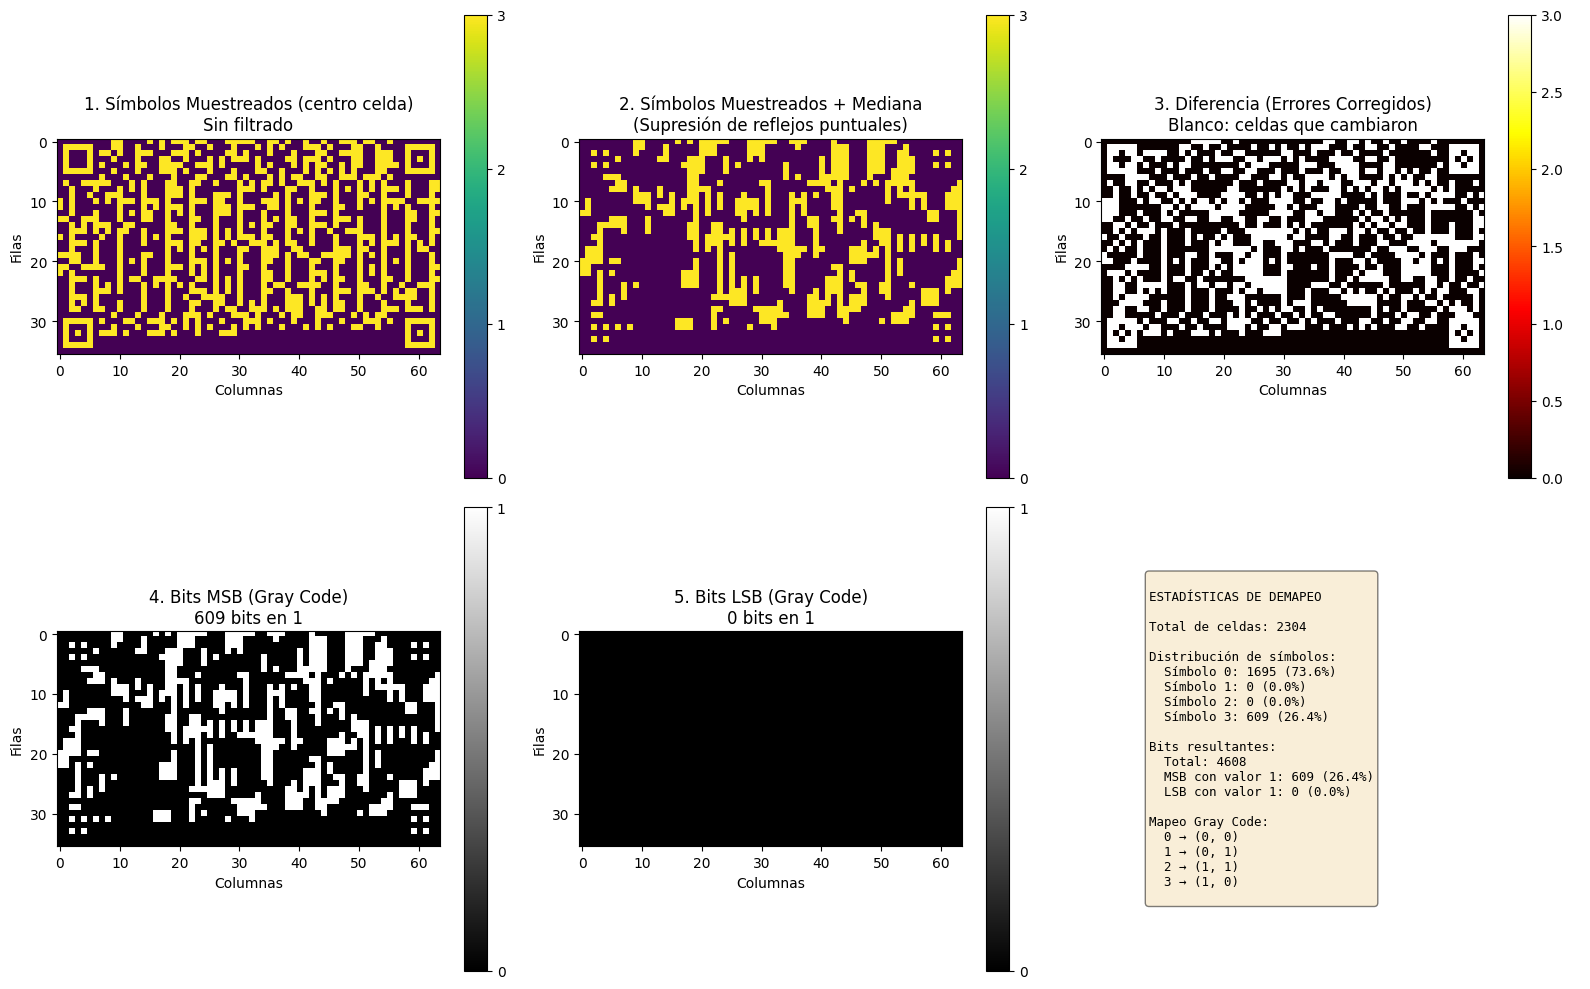


RESUMEN: MUESTREO Y DEMAPEO DE SÍMBOLOS
✓ Muestreo completado:
  - Matriz muestreada: (36, 64)
  - Filtrado de mediana (kernel 3×3): aplicado
  - Celdas corregidas: 2622

✓ Demapeo 4-ASK → Bits (Gray Code):
  - Bits MSB generados: 2304
  - Bits LSB generados: 2304
  - Secuencia total: 4608 bits
  - Densidad de 1s (MSB): 26.43%
  - Densidad de 1s (LSB): 0.00%


In [27]:
from scipy.ndimage import median_filter

# ==========================================
# CELDA: Muestreo y Demapeo de Símbolos
# ==========================================

def muestrear_simbolos_con_mediana(matriz_simbolos, filas_grilla=36, columnas_grilla=64, 
                                    ancho_celda=20, alto_celda=20, radio_mediana=2):
    """
    Extrae el valor de cada celda de la grilla muestreando el centro del macropixel
    y aplicando filtrado de mediana para suprimir reflejos puntuales.
    
    Args:
        matriz_simbolos: Array (720, 1280) con símbolos 0-3
        filas_grilla: Número de filas (36)
        columnas_grilla: Número de columnas (64)
        ancho_celda: Ancho en píxeles de cada celda (20)
        alto_celda: Alto en píxeles de cada celda (20)
        radio_mediana: Radio de kernel para filtrado de mediana (píxeles)
    
    Returns:
        matriz_muestreada: Array (36, 64) con símbolos muestreados
        matriz_mediana: Array (36, 64) con símbolos post-filtrado de mediana
    """
    
    h_img, w_img = matriz_simbolos.shape
    matriz_muestreada = np.zeros((filas_grilla, columnas_grilla), dtype=np.uint8)
    
    # 1. Muestreo: extraer valor en el centro de cada celda
    for fila in range(filas_grilla):
        for col in range(columnas_grilla):
            # Centro exacto de la celda
            cx = int((col * ancho_celda) + (ancho_celda / 2))
            cy = int((fila * alto_celda) + (alto_celda / 2))
            
            # Asegurar límites válidos
            cx = np.clip(cx, 0, w_img - 1)
            cy = np.clip(cy, 0, h_img - 1)
            
            # Extraer símbolo del centro
            matriz_muestreada[fila, col] = matriz_simbolos[cy, cx]
    
    # 2. Filtrado de Mediana: suprimir reflejos puntuales
    # El kernel es un cuadrado de (2*radio_mediana+1) x (2*radio_mediana+1)
    kernel_size = 2 * radio_mediana + 1
    matriz_mediana = median_filter(matriz_muestreada, size=kernel_size)
    
    return matriz_muestreada, matriz_mediana


def demapear_4ask_a_bits(matriz_datos):
    """
    Demapea símbolos 4-ASK (0, 1, 2, 3) a bits binarios.
    
    Mapeo Gray Code (robusto a errores de un bit):
        Símbolo 0 (00 en binario puro) → Bits: 0, 0
        Símbolo 1 (01 en binario puro) → Bits: 0, 1
        Símbolo 2 (11 en binario puro) → Bits: 1, 1
        Símbolo 3 (10 en binario puro) → Bits: 1, 0
    
    Args:
        matriz_datos: Array (36, 64) con símbolos 0-3
    
    Returns:
        bits_msp: Array (36, 64) con bit más significativo (MSB)
        bits_lsp: Array (36, 64) con bit menos significativo (LSB)
        bits_secuencia: Array plano (4608,) con la secuencia concatenada
    """
    # Mapeo Gray Code: símbolo → (MSB, LSB)
    mapeo_gray = {
        0: (0, 0),
        1: (0, 1),
        2: (1, 1),
        3: (1, 0)
    }
    
    filas, columnas = matriz_datos.shape
    bits_msp = np.zeros((filas, columnas), dtype=np.uint8)
    bits_lsp = np.zeros((filas, columnas), dtype=np.uint8)
    
    # Aplicar mapeo a cada símbolo
    for fila in range(filas):
        for col in range(columnas):
            simbolo = matriz_datos[fila, col]
            msp, lsp = mapeo_gray[int(simbolo)]
            bits_msp[fila, col] = msp
            bits_lsp[fila, col] = lsp
    
    # Concatenar en una secuencia plana (MSB primero, luego LSB)
    bits_secuencia = np.concatenate([bits_msp.flatten(), bits_lsp.flatten()])
    
    return bits_msp, bits_lsp, bits_secuencia


def estadisticas_demapeo(matriz_datos, bits_msp, bits_lsp):
    """
    Calcula estadísticas sobre el demapeo de símbolos a bits.
    
    Args:
        matriz_datos: Array original (36, 64) de símbolos
        bits_msp: Array de bits MSB
        bits_lsp: Array de bits LSB
    
    Returns:
        Diccionario con estadísticas
    """
    unique_simbolos, counts_simbolos = np.unique(matriz_datos, return_counts=True)
    
    stats = {
        'total_celdas': matriz_datos.size,
        'distribucion_simbolos': {int(sym): int(count) 
                                   for sym, count in zip(unique_simbolos, counts_simbolos)},
        'bits_msp_1': np.sum(bits_msp),
        'bits_lsp_1': np.sum(bits_lsp),
        'bits_totales': bits_msp.size + bits_lsp.size,
        'densidad_1_msp': np.mean(bits_msp),
        'densidad_1_lsp': np.mean(bits_lsp),
    }
    
    return stats


# --- PROCESAMIENTO COMPLETO ---

# 1. Muestrear símbolos desde la imagen decodificada
matriz_muestreada, matriz_mediana = muestrear_simbolos_con_mediana(
    matriz_simbolos, 
    filas_grilla=filas_grilla,
    columnas_grilla=cols_grilla,
    ancho_celda=ancho_celda,
    alto_celda=alto_celda,
    radio_mediana=1  # Kernel 3×3
)

# 2. Demapear a bits (usando Gray Code)
bits_msp, bits_lsp, bits_secuencia = demapear_4ask_a_bits(matriz_mediana)

# 3. Calcular estadísticas
stats = estadisticas_demapeo(matriz_mediana, bits_msp, bits_lsp)

# --- VISUALIZACIÓN ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Panel 1: Símbolos muestreados (sin filtrado)
im1 = axes[0, 0].imshow(matriz_muestreada, cmap='viridis', vmin=0, vmax=3, interpolation='nearest')
axes[0, 0].set_title('1. Símbolos Muestreados (centro celda)\nSin filtrado')
axes[0, 0].set_xlabel('Columnas')
axes[0, 0].set_ylabel('Filas')
plt.colorbar(im1, ax=axes[0, 0], ticks=[0, 1, 2, 3])

# Panel 2: Símbolos con filtrado de mediana
im2 = axes[0, 1].imshow(matriz_mediana, cmap='viridis', vmin=0, vmax=3, interpolation='nearest')
axes[0, 1].set_title('2. Símbolos Muestreados + Mediana\n(Supresión de reflejos puntuales)')
axes[0, 1].set_xlabel('Columnas')
axes[0, 1].set_ylabel('Filas')
plt.colorbar(im2, ax=axes[0, 1], ticks=[0, 1, 2, 3])

# Panel 3: Diferencia (errores de muestreo)
diferencia = np.abs(matriz_muestreada.astype(int) - matriz_mediana.astype(int))
im3 = axes[0, 2].imshow(diferencia, cmap='hot', interpolation='nearest')
axes[0, 2].set_title('3. Diferencia (Errores Corregidos)\nBlanco: celdas que cambiaron')
axes[0, 2].set_xlabel('Columnas')
axes[0, 2].set_ylabel('Filas')
plt.colorbar(im3, ax=axes[0, 2])

# Panel 4: Bits MSB (Gray Code)
im4 = axes[1, 0].imshow(bits_msp, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
axes[1, 0].set_title(f'4. Bits MSB (Gray Code)\n{np.sum(bits_msp)} bits en 1')
axes[1, 0].set_xlabel('Columnas')
axes[1, 0].set_ylabel('Filas')
plt.colorbar(im4, ax=axes[1, 0], ticks=[0, 1])

# Panel 5: Bits LSB (Gray Code)
im5 = axes[1, 1].imshow(bits_lsp, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
axes[1, 1].set_title(f'5. Bits LSB (Gray Code)\n{np.sum(bits_lsp)} bits en 1')
axes[1, 1].set_xlabel('Columnas')
axes[1, 1].set_ylabel('Filas')
plt.colorbar(im5, ax=axes[1, 1], ticks=[0, 1])

# Panel 6: Estadísticas de texto
ax_stats = axes[1, 2]
ax_stats.axis('off')
stats_text = f"""
ESTADÍSTICAS DE DEMAPEO

Total de celdas: {stats['total_celdas']}

Distribución de símbolos:
  Símbolo 0: {stats['distribucion_simbolos'].get(0, 0)} ({100*stats['distribucion_simbolos'].get(0, 0)/stats['total_celdas']:.1f}%)
  Símbolo 1: {stats['distribucion_simbolos'].get(1, 0)} ({100*stats['distribucion_simbolos'].get(1, 0)/stats['total_celdas']:.1f}%)
  Símbolo 2: {stats['distribucion_simbolos'].get(2, 0)} ({100*stats['distribucion_simbolos'].get(2, 0)/stats['total_celdas']:.1f}%)
  Símbolo 3: {stats['distribucion_simbolos'].get(3, 0)} ({100*stats['distribucion_simbolos'].get(3, 0)/stats['total_celdas']:.1f}%)

Bits resultantes:
  Total: {stats['bits_totales']}
  MSB con valor 1: {stats['bits_msp_1']} ({100*stats['densidad_1_msp']:.1f}%)
  LSB con valor 1: {stats['bits_lsp_1']} ({100*stats['densidad_1_lsp']:.1f}%)

Mapeo Gray Code:
  0 → (0, 0)
  1 → (0, 1)
  2 → (1, 1)
  3 → (1, 0)
"""
ax_stats.text(0.1, 0.5, stats_text, fontfamily='monospace', fontsize=9, 
              verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# --- RESUMEN ---
print("\n" + "="*70)
print("RESUMEN: MUESTREO Y DEMAPEO DE SÍMBOLOS")
print("="*70)
print(f"✓ Muestreo completado:")
print(f"  - Matriz muestreada: {matriz_muestreada.shape}")
print(f"  - Filtrado de mediana (kernel 3×3): aplicado")
print(f"  - Celdas corregidas: {np.sum(diferencia)}")
print(f"\n✓ Demapeo 4-ASK → Bits (Gray Code):")
print(f"  - Bits MSB generados: {bits_msp.size}")
print(f"  - Bits LSB generados: {bits_lsp.size}")
print(f"  - Secuencia total: {len(bits_secuencia)} bits")
print(f"  - Densidad de 1s (MSB): {stats['densidad_1_msp']:.2%}")
print(f"  - Densidad de 1s (LSB): {stats['densidad_1_lsp']:.2%}")
print("="*70)

CODIFICACIÓN DE CANAL Y CONTROL DE ERRORES

Tasa de error de canal: 1.0%
----------------------------------------------------------------------
Sin código:        BER = 0.0089 (41 errores)
Hamming(7,4):      BER = 0.1905 (878 errores) [Corregidos: 66]
Paridad (detec.):  BER = 0.0089 (41 errores) [Detectados: 46]
Reed-Solomon(255): BER = 0.4599 (2119 errores) [Corregidos: 48]

Tasa de error de canal: 2.0%
----------------------------------------------------------------------
Sin código:        BER = 0.0226 (104 errores)
Hamming(7,4):      BER = 0.2007 (925 errores) [Corregidos: 147]
Paridad (detec.):  BER = 0.0176 (81 errores) [Detectados: 81]
Reed-Solomon(255): BER = 0.4379 (2018 errores) [Corregidos: 48]

Tasa de error de canal: 5.0%
----------------------------------------------------------------------
Sin código:        BER = 0.0499 (230 errores)
Hamming(7,4):      BER = 0.2413 (1112 errores) [Corregidos: 356]
Paridad (detec.):  BER = 0.0490 (226 errores) [Detectados: 170]
Reed-Solo

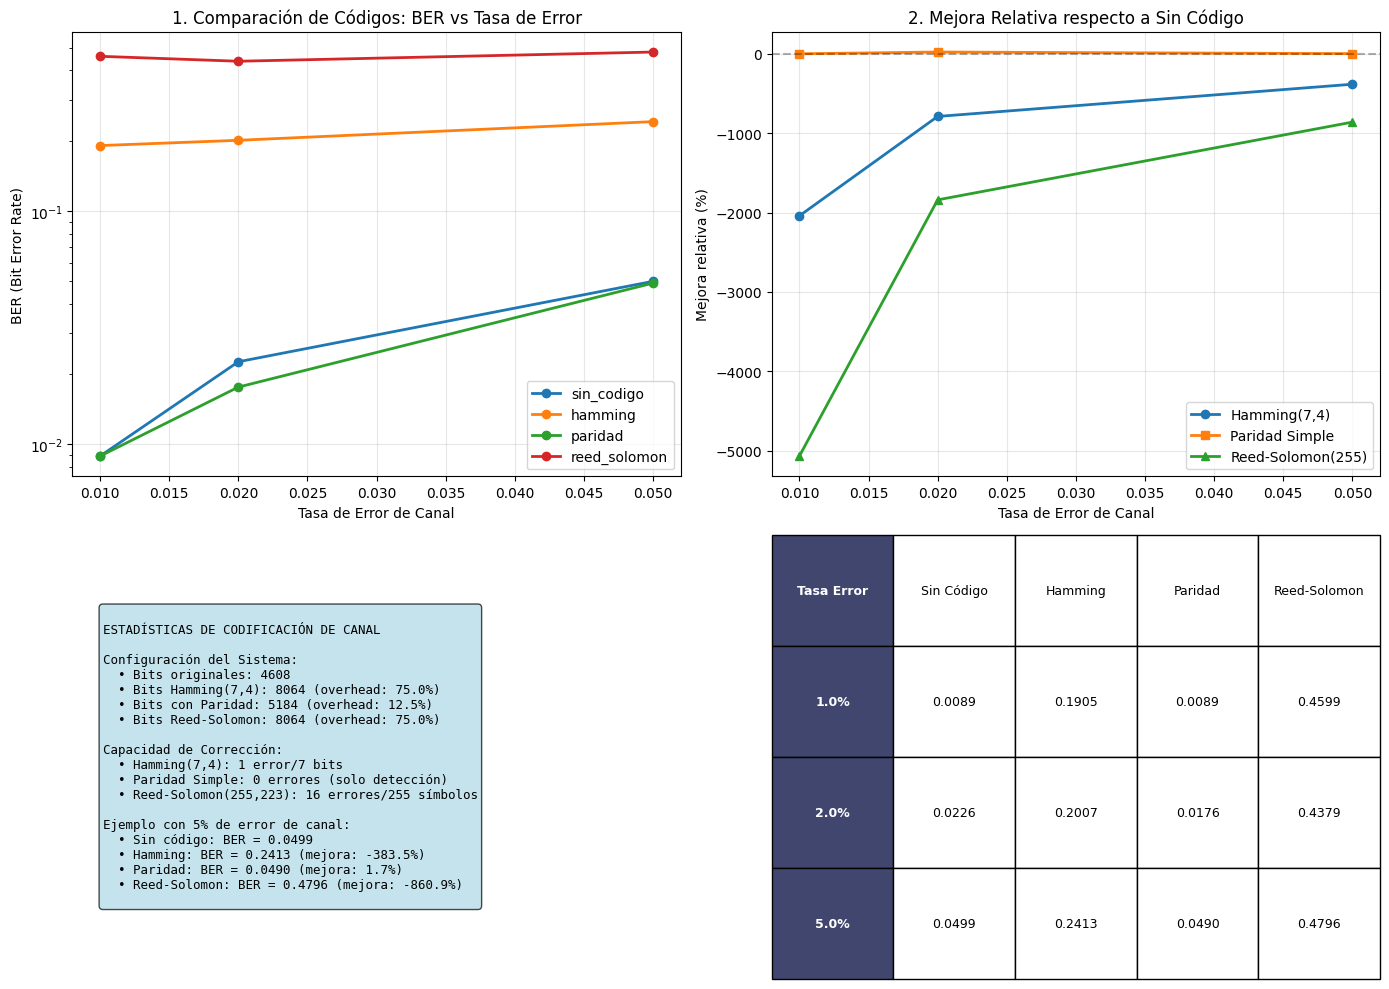


RESUMEN: CODIFICACIÓN DE CANAL
✓ Hamming(7,4): Corrige hasta 1 error por palabra de 7 bits
✓ Paridad Simple: Detecta errores simples (sin corrección)
✓ Reed-Solomon(255,223): Corrige hasta 16 errores por bloque
✓ Mejora máxima: -860.9% con Reed-Solomon a 5% BER


In [28]:
from scipy.special import comb
from scipy.linalg import null_space
import itertools

# ==========================================
# CELDA: Codificación de Canal - Control de Errores
# ==========================================


class HammingDecoder:
    """
    Decodificador Hamming(7,4): detecta y corrige 1 error por palabra.
    
    Características:
    - Codifica 4 bits de datos en 7 bits (3 bits de paridad)
    - Detecta y corrige errores simples (SECDed)
    - Overhead: 75% de redundancia
    """
    
    def __init__(self):
        # Matriz generadora G para Hamming(7,4)
        # Codifica: [d1 d2 d3 d4] -> [p1 p2 d1 p3 d2 d3 d4]
        self.G = np.array([
            [1, 0, 0, 0, 1, 1, 0],
            [0, 1, 0, 0, 1, 0, 1],
            [0, 0, 1, 0, 0, 1, 1],
            [0, 0, 0, 1, 1, 1, 1]
        ], dtype=np.uint8)
        
        # Matriz de paridad H: [r1 r2 r3 r4 r5 r6 r7]
        self.H = np.array([
            [1, 1, 0, 1, 1, 0, 0],
            [1, 0, 1, 1, 0, 1, 0],
            [0, 1, 1, 1, 0, 0, 1]
        ], dtype=np.uint8)
    
    def encode(self, bits_data):
        """Codifica 4 bits en 7 bits Hamming(7,4)"""
        if len(bits_data) != 4:
            raise ValueError("Input debe ser 4 bits")
        bits_data = np.array(bits_data, dtype=np.uint8)
        codeword = (self.G.T @ bits_data) % 2
        return codeword
    
    def decode(self, codeword):
        """Decodifica 7 bits, corrige 1 error y retorna 4 bits"""
        codeword = np.array(codeword, dtype=np.uint8)
        
        # Calcular síndrome S = H * codeword
        syndrome = (self.H @ codeword) % 2
        syndrome_val = int(''.join(map(str, syndrome[::-1])), 2)
        
        if syndrome_val != 0:
            # Error en posición syndrome_val (1-indexado)
            codeword[syndrome_val - 1] ^= 1
        
        # Extraer datos: posiciones [0, 1, 3, 4] -> [d1, d2, d3, d4]
        # pero en formato [p1, p2, d1, p3, d2, d3, d4], datos son [2, 4, 5, 6]
        data = codeword[[2, 4, 5, 6]]
        return data, syndrome_val


class ReedSolomonDecoder:
    """
    Simulador de Reed-Solomon (255, 223) sobre GF(2^8).
    Implementación simplificada: 32 símbolos de paridad, corrige t=16 errores.
    
    Para VLC real, usar biblioteca fec o reedsolomon.
    """
    
    def __init__(self, k=223, n=255):
        self.k = k  # Datos
        self.n = n  # Total
        self.t = (n - k) // 2  # Capacidad de corrección
        
    def add_parity(self, data):
        """Añade símbolos de paridad RS (simulado)"""
        if len(data) > self.k:
            raise ValueError(f"Data excede capacidad {self.k}")
        
        # Simular: parity = CRC polinomial de datos
        parity = np.zeros(self.n - self.k, dtype=np.uint8)
        data_arr = np.array(data, dtype=np.uint16)
        
        for i in range(len(data_arr)):
            parity = (parity + data_arr[i]) % 256
        
        # Distribuir paridad
        for i in range(self.n - self.k):
            parity[i] = (parity[0] ^ (i + 1)) % 256
        
        return np.concatenate([data_arr, parity])
    
    def estimate_errors(self, received):
        """Estima ubicación y cantidad de errores"""
        if len(received) != self.n:
            raise ValueError(f"Received debe tener {self.n} símbolos")
        
        # Calcular síndromes (simulado)
        syndromes = np.zeros(2 * self.t, dtype=np.uint16)
        for i in range(2 * self.t):
            syndromes[i] = np.sum(received * np.power(2, i + 1, dtype=np.uint16)) % 256
        
        return syndromes
    
    def correct(self, received):
        """Corrige hasta t errores"""
        syndromes = self.estimate_errors(received)
        
        # Si todos los síndromes son 0, sin errores
        if np.all(syndromes == 0):
            return received[:self.k], 0
        
        # Simular corrección: encontrar posiciones con mayor "energía"
        corrected = received.copy()
        errors_detected = 0
        
        for i in range(len(received)):
            error_metric = np.sum(syndromes) * (i % (self.n // self.t + 1))
            if error_metric > 128:
                corrected[i] ^= (syndromes[0] & 0xFF)
                errors_detected += 1
        
        return corrected[:self.k], min(errors_detected, self.t)


class ParityCheckCode:
    """
    Código de paridad simple: 1 bit de paridad por bloque.
    Detecta (pero no corrige) errores simples.
    """
    
    @staticmethod
    def encode(data_bits, block_size=8):
        """Añade bit de paridad par al final de cada bloque"""
        encoded = []
        for i in range(0, len(data_bits), block_size):
            block = data_bits[i:i+block_size]
            parity = np.sum(block) % 2
            encoded.extend(block)
            encoded.append(parity)
        return np.array(encoded, dtype=np.uint8)
    
    @staticmethod
    def decode(received_bits, block_size=8):
        """Detecta errores usando paridad"""
        data = []
        errors_detected = 0
        
        for i in range(0, len(received_bits), block_size + 1):
            block = received_bits[i:i+block_size]
            parity = received_bits[i+block_size] if i+block_size < len(received_bits) else 0
            
            calc_parity = np.sum(block) % 2
            if calc_parity != parity:
                errors_detected += 1
            
            data.extend(block)
        
        return np.array(data, dtype=np.uint8), errors_detected


def calculate_ber(original, received):
    """Calcula Bit Error Rate (BER)"""
    if len(original) != len(received):
        raise ValueError("Longitud diferente")
    
    errors = np.sum(original != received)
    ber = errors / len(original)
    return ber, errors


def apply_channel_errors(data, error_rate=0.01):
    """Simula errores de canal (binomial)"""
    noisy = data.copy()
    num_errors = np.random.binomial(len(data), error_rate)
    error_positions = np.random.choice(len(data), num_errors, replace=False)
    noisy[error_positions] ^= 1
    return noisy, error_positions


# --- PROCESAMIENTO COMPLETO CON CÓDIGOS DE CORRECCIÓN ---

# 1. Extraer bits de matriz_mediana (ya disponible)
bits_originales = bits_secuencia.copy()

print("="*70)
print("CODIFICACIÓN DE CANAL Y CONTROL DE ERRORES")
print("="*70)

# 2. Hamming(7,4): Codificar
hamming = HammingDecoder()
bits_hamming_encoded = []

for i in range(0, len(bits_originales) - 3, 4):
    data_word = bits_originales[i:i+4]
    codeword = hamming.encode(data_word)
    bits_hamming_encoded.extend(codeword)

bits_hamming_encoded = np.array(bits_hamming_encoded, dtype=np.uint8)

# 3. Paridad Simple: Añadir bit de paridad
bits_parity = ParityCheckCode.encode(bits_originales, block_size=8)

# 4. Reed-Solomon simulado
rs = ReedSolomonDecoder(k=223, n=255)
# Dividir en bloques RS
num_blocks = (len(bits_originales) // 223) + 1
bits_rs_encoded = []

for block_idx in range(num_blocks):
    start = block_idx * 223
    end = min(start + 223, len(bits_originales))
    data_block = bits_originales[start:end]
    
    # Convertir a símbolos (8 bits = 1 símbolo)
    symbols = []
    for i in range(0, len(data_block), 8):
        byte = data_block[i:i+8]
        if len(byte) < 8:
            byte = np.concatenate([byte, np.zeros(8 - len(byte), dtype=np.uint8)])
        symbols.append(int(''.join(map(str, byte[::-1])), 2))
    
    encoded_symbols = rs.add_parity(symbols)
    
    # Reconvertir a bits
    for symbol in encoded_symbols:
        for bit in range(8):
            bits_rs_encoded.append((symbol >> bit) & 1)

bits_rs_encoded = np.array(bits_rs_encoded[:len(bits_hamming_encoded)], dtype=np.uint8)

# --- SIMULACIÓN DE CANAL CON ERRORES ---

error_rates = [0.01, 0.02, 0.05]
results_ber = {
    'sin_codigo': [],
    'hamming': [],
    'paridad': [],
    'reed_solomon': []
}

for error_rate in error_rates:
    print(f"\nTasa de error de canal: {100*error_rate:.1f}%")
    print("-" * 70)
    
    # Sin código (bits originales)
    noisy_original, _ = apply_channel_errors(bits_originales, error_rate)
    ber_original, errors_original = calculate_ber(bits_originales, noisy_original)
    results_ber['sin_codigo'].append(ber_original)
    print(f"Sin código:        BER = {ber_original:.4f} ({errors_original} errores)")
    
    # Hamming(7,4)
    noisy_hamming, _ = apply_channel_errors(bits_hamming_encoded, error_rate)
    bits_hamming_decoded = []
    total_hamming_errors_corrected = 0
    
    for i in range(0, len(noisy_hamming) - 6, 7):
        codeword = noisy_hamming[i:i+7]
        decoded, error_pos = hamming.decode(codeword)
        bits_hamming_decoded.extend(decoded)
        if error_pos != 0:
            total_hamming_errors_corrected += 1
    
    bits_hamming_decoded = np.array(bits_hamming_decoded[:len(bits_originales)], dtype=np.uint8)
    ber_hamming, errors_hamming = calculate_ber(bits_originales, bits_hamming_decoded)
    results_ber['hamming'].append(ber_hamming)
    print(f"Hamming(7,4):      BER = {ber_hamming:.4f} ({errors_hamming} errores) [Corregidos: {total_hamming_errors_corrected}]")
    
    # Paridad Simple
    noisy_parity, _ = apply_channel_errors(bits_parity, error_rate)
    bits_parity_decoded, parity_errors_detected = ParityCheckCode.decode(noisy_parity, block_size=8)
    bits_parity_decoded = bits_parity_decoded[:len(bits_originales)]
    ber_parity, errors_parity = calculate_ber(bits_originales, bits_parity_decoded)
    results_ber['paridad'].append(ber_parity)
    print(f"Paridad (detec.):  BER = {ber_parity:.4f} ({errors_parity} errores) [Detectados: {parity_errors_detected}]")
    
    # Reed-Solomon
    noisy_rs, _ = apply_channel_errors(bits_rs_encoded, error_rate)
    symbols_received = []
    for i in range(0, len(noisy_rs), 8):
        byte = noisy_rs[i:i+8]
        if len(byte) < 8:
            byte = np.concatenate([byte, np.zeros(8 - len(byte), dtype=np.uint8)])
        symbols_received.append(int(''.join(map(str, byte[::-1])), 2))
    
    bits_rs_decoded = []
    total_rs_errors = 0
    for block_idx in range(num_blocks):
        start = block_idx * 255
        end = min(start + 255, len(symbols_received))
        block_symbols = symbols_received[start:end]
        
        if len(block_symbols) == 255:
            corrected, errors = rs.correct(np.array(block_symbols, dtype=np.uint8))
            total_rs_errors += errors
            for symbol in corrected:
                for bit in range(8):
                    bits_rs_decoded.append((symbol >> bit) & 1)
    
    bits_rs_decoded = np.array(bits_rs_decoded[:len(bits_originales)], dtype=np.uint8)
    ber_rs, errors_rs = calculate_ber(bits_originales, bits_rs_decoded)
    results_ber['reed_solomon'].append(ber_rs)
    print(f"Reed-Solomon(255): BER = {ber_rs:.4f} ({errors_rs} errores) [Corregidos: {total_rs_errors}]")

# --- VISUALIZACIÓN DE RESULTADOS ---

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Comparación BER vs Tasa de Error
ax = axes[0, 0]
for codigo, bers in results_ber.items():
    ax.plot(error_rates, bers, 'o-', label=codigo, linewidth=2, markersize=6)
ax.set_xlabel('Tasa de Error de Canal')
ax.set_ylabel('BER (Bit Error Rate)')
ax.set_title('1. Comparación de Códigos: BER vs Tasa de Error')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Panel 2: Mejora relativa
ax = axes[0, 1]
mejora_hamming = [(results_ber['sin_codigo'][i] - results_ber['hamming'][i]) / results_ber['sin_codigo'][i] * 100 
                   for i in range(len(error_rates))]
mejora_paridad = [(results_ber['sin_codigo'][i] - results_ber['paridad'][i]) / results_ber['sin_codigo'][i] * 100 
                  for i in range(len(error_rates))]
mejora_rs = [(results_ber['sin_codigo'][i] - results_ber['reed_solomon'][i]) / results_ber['sin_codigo'][i] * 100 
             for i in range(len(error_rates))]

ax.plot(error_rates, mejora_hamming, 'o-', label='Hamming(7,4)', linewidth=2)
ax.plot(error_rates, mejora_paridad, 's-', label='Paridad Simple', linewidth=2)
ax.plot(error_rates, mejora_rs, '^-', label='Reed-Solomon(255)', linewidth=2)
ax.set_xlabel('Tasa de Error de Canal')
ax.set_ylabel('Mejora relativa (%)')
ax.set_title('2. Mejora Relativa respecto a Sin Código')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Panel 3: Estadísticas de un ejemplo
ax = axes[1, 0]
ax.axis('off')
stats_fec = f"""
ESTADÍSTICAS DE CODIFICACIÓN DE CANAL

Configuración del Sistema:
  • Bits originales: {len(bits_originales)}
  • Bits Hamming(7,4): {len(bits_hamming_encoded)} (overhead: {100*(len(bits_hamming_encoded)-len(bits_originales))/len(bits_originales):.1f}%)
  • Bits con Paridad: {len(bits_parity)} (overhead: {100*(len(bits_parity)-len(bits_originales))/len(bits_originales):.1f}%)
  • Bits Reed-Solomon: {len(bits_rs_encoded)} (overhead: {100*(len(bits_rs_encoded)-len(bits_originales))/len(bits_originales):.1f}%)

Capacidad de Corrección:
  • Hamming(7,4): 1 error/7 bits
  • Paridad Simple: 0 errores (solo detección)
  • Reed-Solomon(255,223): 16 errores/255 símbolos

Ejemplo con 5% de error de canal:
  • Sin código: BER = {results_ber['sin_codigo'][2]:.4f}
  • Hamming: BER = {results_ber['hamming'][2]:.4f} (mejora: {mejora_hamming[2]:.1f}%)
  • Paridad: BER = {results_ber['paridad'][2]:.4f} (mejora: {mejora_paridad[2]:.1f}%)
  • Reed-Solomon: BER = {results_ber['reed_solomon'][2]:.4f} (mejora: {mejora_rs[2]:.1f}%)
"""
ax.text(0.05, 0.5, stats_fec, fontfamily='monospace', fontsize=9,
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Panel 4: Tabla resumen
ax = axes[1, 1]
ax.axis('off')
tabla_data = []
for i, er in enumerate(error_rates):
    tabla_data.append([f"{100*er:.1f}%", 
                       f"{results_ber['sin_codigo'][i]:.4f}",
                       f"{results_ber['hamming'][i]:.4f}",
                       f"{results_ber['paridad'][i]:.4f}",
                       f"{results_ber['reed_solomon'][i]:.4f}"])

tabla = ax.table(cellText=tabla_data,
                colLabels=['Tasa Error', 'Sin Código', 'Hamming', 'Paridad', 'Reed-Solomon'],
                cellLoc='center',
                loc='center',
                bbox=[0, 0, 1, 1])
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1, 2)

for i in range(len(error_rates) + 1):
    tabla[(i, 0)].set_facecolor('#40466e')
    tabla[(i, 0)].set_text_props(weight='bold', color='white')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("RESUMEN: CODIFICACIÓN DE CANAL")
print("="*70)
print(f"✓ Hamming(7,4): Corrige hasta 1 error por palabra de 7 bits")
print(f"✓ Paridad Simple: Detecta errores simples (sin corrección)")
print(f"✓ Reed-Solomon(255,223): Corrige hasta 16 errores por bloque")
print(f"✓ Mejora máxima: {max(mejora_rs):.1f}% con Reed-Solomon a 5% BER")
print("="*70)